In [1]:
import pandas as pd
import numpy as  np
import os


In [2]:
training_data_base_path = r'C:\Users\timur\Documents\GitHub\EmailSentin\data\local_data\labeled_partitions_finished' 


In [3]:
csv_files = [f for f in os.listdir(training_data_base_path) if f.endswith(".csv")]

# Load each CSV into a separate DataFrame and store in a list
dataframes = [pd.read_csv(os.path.join(training_data_base_path, f)) for f in csv_files]

# Concatenate all DataFrames along axis=0 (stack them vertically)
combined_df = pd.concat(dataframes, axis=0, ignore_index=True)

# Optional: check result
print(f"Loaded {len(csv_files)} files.")
print(f"Combined DataFrame shape: {combined_df.shape}")


formality_map = {
    "Very Formal": 1,
    "Formal": 1,
    "Informal": 0,
    "Very Informal": 0
}

# Filter out rows where label is 'Neutral'
filtered_df = combined_df[combined_df['label'] != 'Neutral'].copy()

# Assign binary labels using the map
filtered_df['formality_binary'] = filtered_df['label'].map(formality_map)

# Optional: check result
print(filtered_df['formality_binary'].value_counts())
print(f"New shape after removing 'Neutral': {filtered_df.shape}")
filtered_df = filtered_df.reset_index(drop=True)[['text','formality_binary','label']]
label_fix_map = {
    "Informal#Informal(Binary)": "Informal",
    "Neutral#Very Formal": "Very Formal",
    "Formal#Informal(Binary)#Neutral": "Informal"
}

# Apply the mapping
filtered_df['label'] = filtered_df['label'].replace(label_fix_map)

Loaded 10 files.
Combined DataFrame shape: (1479, 5)
0.0    478
1.0    399
Name: formality_binary, dtype: int64
New shape after removing 'Neutral': (886, 5)


In [4]:
filtered_df

,text,formality_binary,label
0,"Texas version of ""Survivor"":\n\nContestants ha...",0.0,Very Informal
1,"As you may have noticed, there was a network e...",1.0,Formal
2,i like that feeling...as long as someone doesn...,0.0,Informal
3,What time are you heading out today?,0.0,Informal
4,You are scheduled to attend the 2nd Annual Glo...,1.0,Formal
...,...,...,...
881,"Neartown neighbors,\n\nTurn on Channel 11 news...",1.0,Formal
882,"Gentlemen,\n\nAttached for your review is a dr...",1.0,Very Formal
883,you could bbq a big piece of meat like you did...,0.0,Very Informal
884,not yet...\n\n\nI think Webb and I will need t...,0.0,Informal


In [5]:
filtered_df['label'].value_counts()

Informal         422
Formal           339
Very Formal       61
Very Informal     59
Name: label, dtype: int64

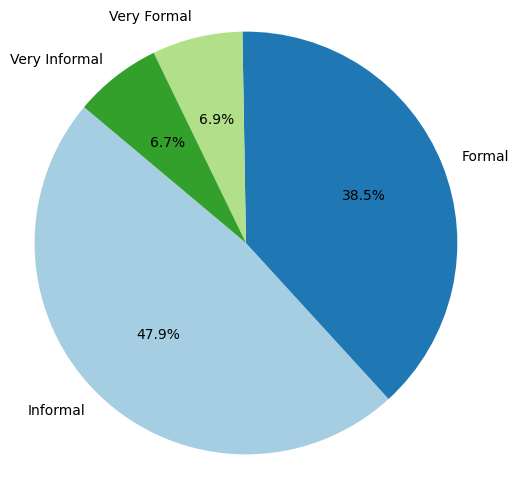

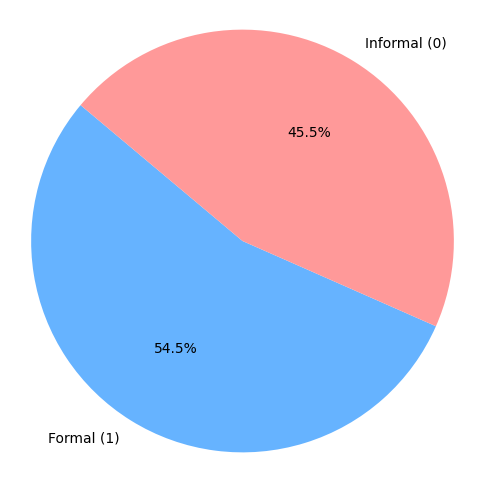

In [30]:
import matplotlib.pyplot as plt

# Pie chart for original label distribution
label_counts = filtered_df['label'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)

plt.axis('equal')
plt.show()

# Pie chart for binary label distribution
binary_counts = filtered_df['formality_binary'].value_counts()
binary_labels = ['Formal (1)', 'Informal (0)'] if 1 in binary_counts.index and 0 in binary_counts.index else binary_counts.index.astype(str)
plt.figure(figsize=(6, 6))
plt.pie(binary_counts, labels=binary_labels, autopct='%1.1f%%', startangle=140, colors=['#66b3ff', '#ff9999'])

plt.axis('equal')
plt.show()

In [37]:
filtered_df['char_count']

0      209
1      599
2      219
3       36
4      790
      ... 
881    702
882    520
883    129
884    214
885    200
Name: char_count, Length: 886, dtype: int64

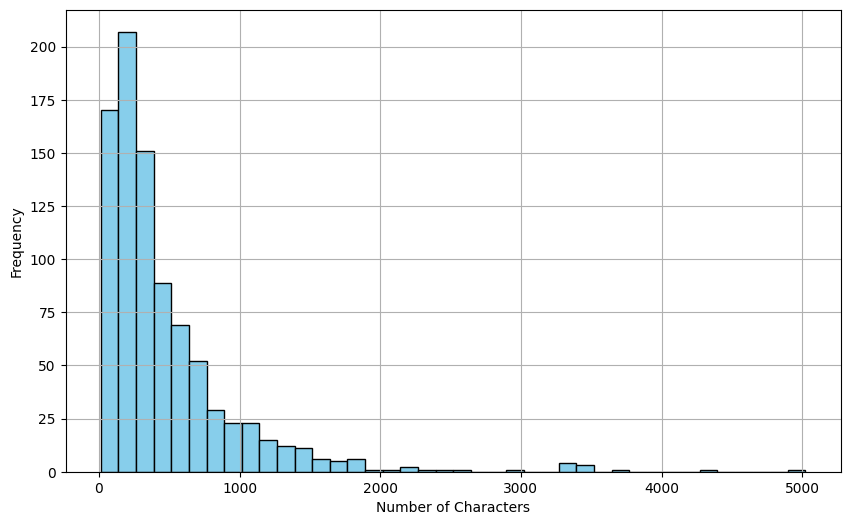

In [33]:
# Compute character counts
filtered_df['char_count'] = filtered_df['text'].apply(len)

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(filtered_df['char_count'], bins=40, color='skyblue', edgecolor='black')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

[nltk_data] Downloading package punkt to C:\Users\timur/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\timur/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


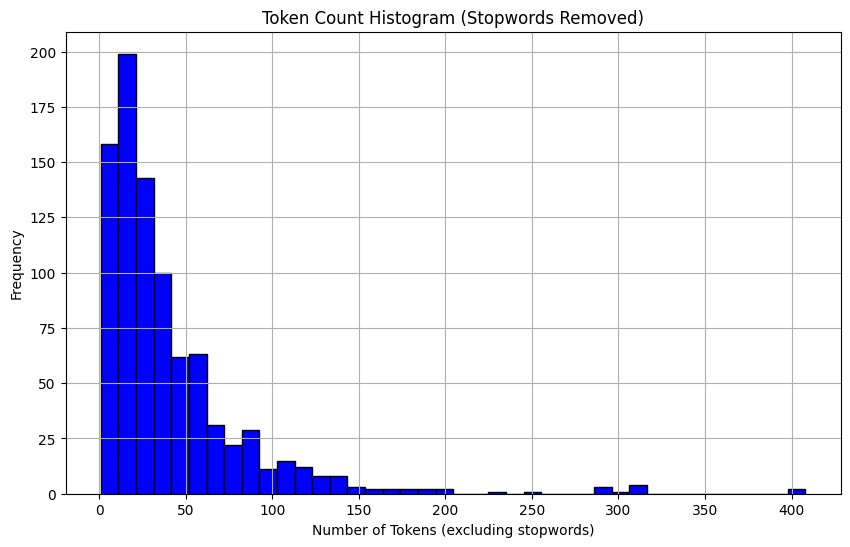

In [7]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import matplotlib.pyplot as plt

# Make sure you have downloaded the required NLTK data
nltk.download('punkt')
nltk.download('stopwords')

# Get English stopwords
stop_words = set(stopwords.words('english'))

# Function to count non-stopword tokens
def count_tokens(text):
    tokens = word_tokenize(text)
    filtered_tokens = [word for word in tokens if word.lower() not in stop_words and word.isalpha()]
    return len(filtered_tokens)

# Compute token counts
filtered_df['token_count'] = filtered_df['text'].apply(count_tokens)

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(filtered_df['token_count'], bins=40, color='blue', edgecolor='black')
plt.xlabel('Number of Tokens (excluding stopwords)')
plt.ylabel('Frequency')
plt.grid(True)
plt.title('Token Count Histogram (Stopwords Removed)')
plt.show()

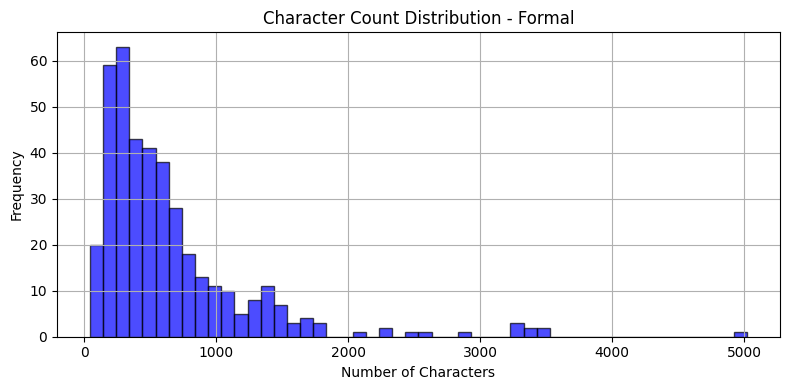

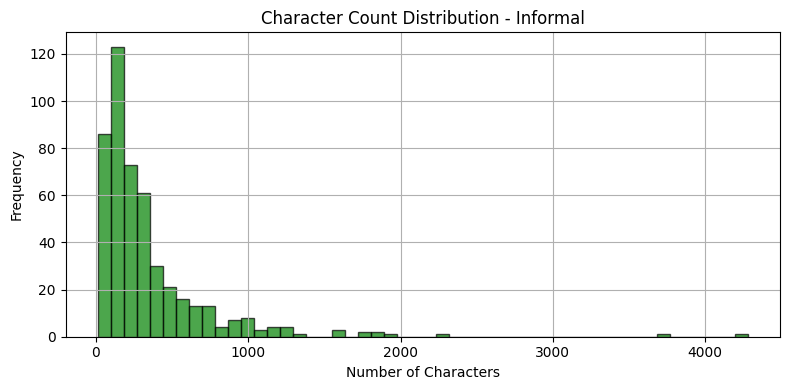

In [35]:

filtered_df['char_count'] = filtered_df['text'].apply(len)

# Split based on binary formality
formal_df = filtered_df[filtered_df['formality_binary'] == 1]
informal_df = filtered_df[filtered_df['formality_binary'] == 0]

# Plot Formal
plt.figure(figsize=(8, 4))
plt.hist(formal_df['char_count'], bins=50, color='blue', edgecolor='black', alpha=0.7)
plt.title('Character Count Distribution - Formal')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Informal
plt.figure(figsize=(8, 4))
plt.hist(informal_df['char_count'], bins=50, color='green', edgecolor='black', alpha=0.7)
plt.title('Character Count Distribution - Informal')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

In [38]:
from scipy.stats import pearsonr


# Drop rows with NaN or infinite values in the relevant columns
df_clean = filtered_df[['char_count', 'formality_binary']].replace([np.inf, -np.inf], np.nan).dropna()

corr, p_value = pearsonr(df_clean['char_count'], df_clean['formality_binary'])
print(f"Point-Biserial Correlation: {corr:.4f}, p-value: {p_value:.4g}")

Point-Biserial Correlation: 0.2835, p-value: 1.144e-17
